# Домашнее задание: Классификация на Titanic

В этом задании вы будете работать с датасетом Titanic (можно загрузить через `seaborn.load_dataset('titanic')` или с Kaggle). Цель — обучить классификаторы и научиться интерпретировать результаты моделей.

**Модели:** Logistic Regression, SVM, kNN, Decision Tree.

**Целевая переменная:** `Survived`


### Задание 1 - смотрим на датасет (0.5 б)
Загрузите датасет, выведите его форму, типы данных, количество пропусков и уникальные значения по колонкам.

In [1]:
import pandas as pd

In [2]:
url = "https://raw.github.com/mattdelhey/kaggle-titanic/master/Data/train.csv"
df = pd.read_csv(url)
df.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
  #Форма
  df.shape


(891, 11)

In [5]:
# Типы данных
df.dtypes

,0
survived,int64
pclass,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
cabin,object


In [7]:
# Количество пропусков
df.isnull().sum()


,0
survived,0
pclass,0
name,0
sex,0
age,177
sibsp,0
parch,0
ticket,0
fare,0
cabin,687


Много пропусков в cabin и age

In [8]:
# Уникальные значения по каждой колонке
df.nunique()

,0
survived,2
pclass,3
name,891
sex,2
age,88
sibsp,7
parch,7
ticket,681
fare,248
cabin,147


### Задание 2 - работаем с признаками (0.5 б)

Удалите ненужные признаки (`Name`, `Ticket`, `Cabin`). Обработайте пропуски и закодируйте категориальные признаки (`Sex`, `Embarked`, `Pclass`, и т.п.).

In [10]:
df = df.drop(['name', 'ticket', 'cabin'], axis=1)


In [13]:
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipython-input-13-1654433547.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [16]:
# так как всего 2 пропуска
df.dropna(subset=['embarked'], inplace=True)


In [17]:
'''Кодировка sex бинарная, так как 2 значения только'''
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [18]:
'''Embarked имеет 3 значения: C, Q, S. One-hot encoding создаст отдельные столбцы для них отдельные столбцы'''
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [19]:
pd.get_dummies(df, columns=['pclass'], prefix='pclass', drop_first=True)

,survived,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,pclass_2,pclass_3
0,0,0,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,1,26.0,0,0,7.9250,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,True,False,False
4,0,0,35.0,0,0,8.0500,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,0,27.0,0,0,13.0000,False,True,True,False
887,1,1,19.0,0,0,30.0000,False,True,False,False
888,0,1,28.0,1,2,23.4500,False,True,False,True
889,1,0,26.0,0,0,30.0000,False,False,False,False


### Задание 3 - выбираем целевую переменную (1 б)

Целевая переменная — `survived`. Нарисуйте графики:
 - зависимости целевой переменной от признака `sex` (или `sex_male`)
 - зависимости целевой переменной от признака `pclass`
 - зависимости целевой переменной от признака `sibsp`

Прокомментируйте каждый график

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

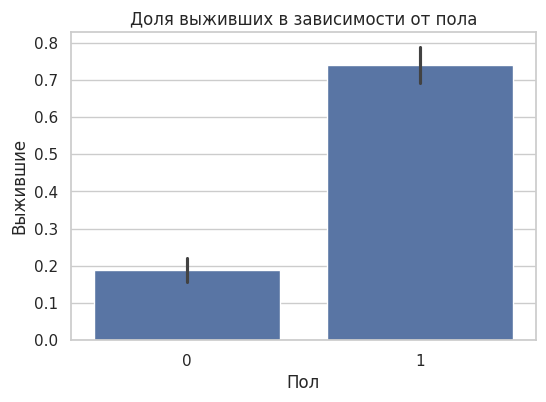

In [24]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='survived', data=df)
plt.title('Доля выживших в зависимости от пола')
plt.ylabel('Выжившие')
plt.xlabel('Пол')
plt.show()

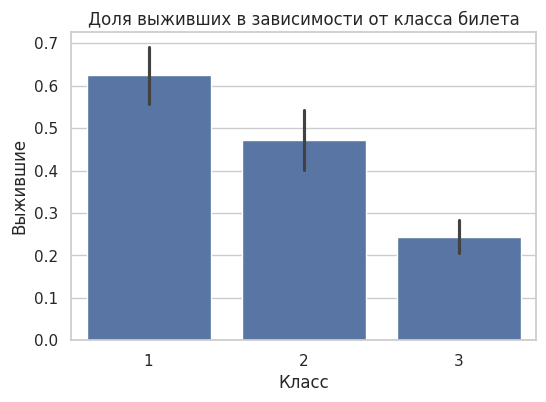

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Доля выживших в зависимости от класса билета')
plt.ylabel('Выжившие')
plt.xlabel('Класс')
plt.show()

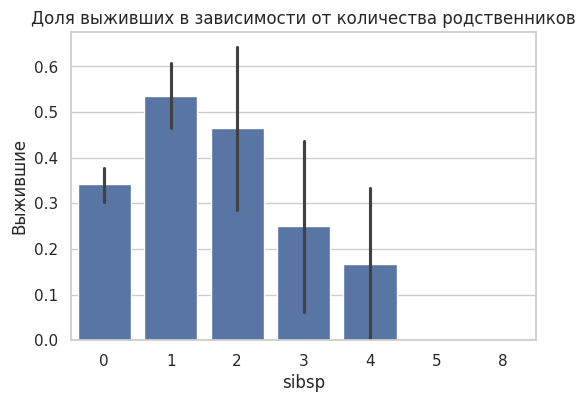

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(x='sibsp', y='survived', data=df)
plt.title('Доля выживших в зависимости от количества родственников')
plt.ylabel('Выжившие')
plt.xlabel('sibsp')
plt.show()


Разделите данные на фичи и таргет.

In [29]:
# Целевая переменная
y = df['survived']

# Признаки
X = df.drop('survived', axis=1)

### Задание 4 - делим выборку на обучение и тест (1 б)

Разделите выборку на train/test (70/30). Не забудьте сделать так, чтобы в трейн и тест попало примерно одинаковое количество наблюдений 0 и 1 классов.

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Нарисуйте получившееся распределение классов на трейне и на тесте

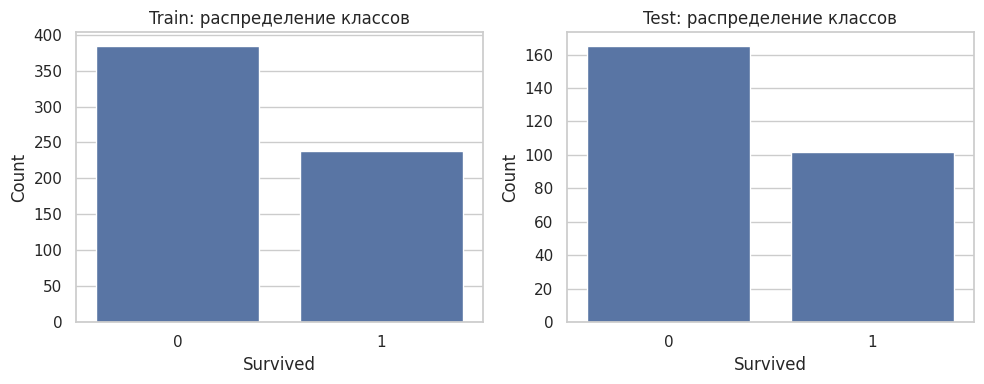

In [31]:
plt.figure(figsize=(10, 4))

# Распределение в train
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Train: распределение классов")
plt.xlabel("Survived")
plt.ylabel("Count")

# Распределение в test
plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title("Test: распределение классов")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Видно, что распределение классов 0 и 1 в обеих выборках очень похоже, значит, что параметр stratify=y отработал правильно

### Задание 5 - Logistic Regression (1 б)

  - Обучите модель логистической регрессии.
  - Выберите оптимальную метрику для решаемой задачи, обоснуйте свой выбор и выведите эту метрику на train и test.

In [33]:
from sklearn.linear_model import LogisticRegression
# Создание и обучение модели
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [34]:
# Предсказания
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [35]:
'''Оптимальной метрикой является F1-score, так как классы 0 и 1 и они несбалансированы.
F1-score учитывает как precision, так и recall полезен, когда важно избежать
как ложноположительных, так и ложноотрицательных прогнозов'''

'Оптимальной метрикой является F1-score, так как классы 0 и 1 и они несбалансированы.\nF1-score учитывает как precision, так и recall полезен, когда важно избежать\nкак ложноположительных, так и ложноотрицательных прогнозов'

### Задание 6 - SVM  (0.5 б)

Обучите модель SVM, сравните с результатами логистической регрессии.

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# Обучение модели
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [41]:
# Предсказания
svm_pred_train = svm_model.predict(X_train)
svm_pred_test = svm_model.predict(X_test)

In [42]:
a=f1_score(y_train, svm_pred_train)
b=f1_score(y_test, svm_pred_test)

In [43]:
print(a,b)

0.7192982456140351 0.6836734693877551


### Задание7 - Desicion Tree (3 б 1 + 2 доп)

Обучите дерево решений, визуализируйте его структуру. (1 б)

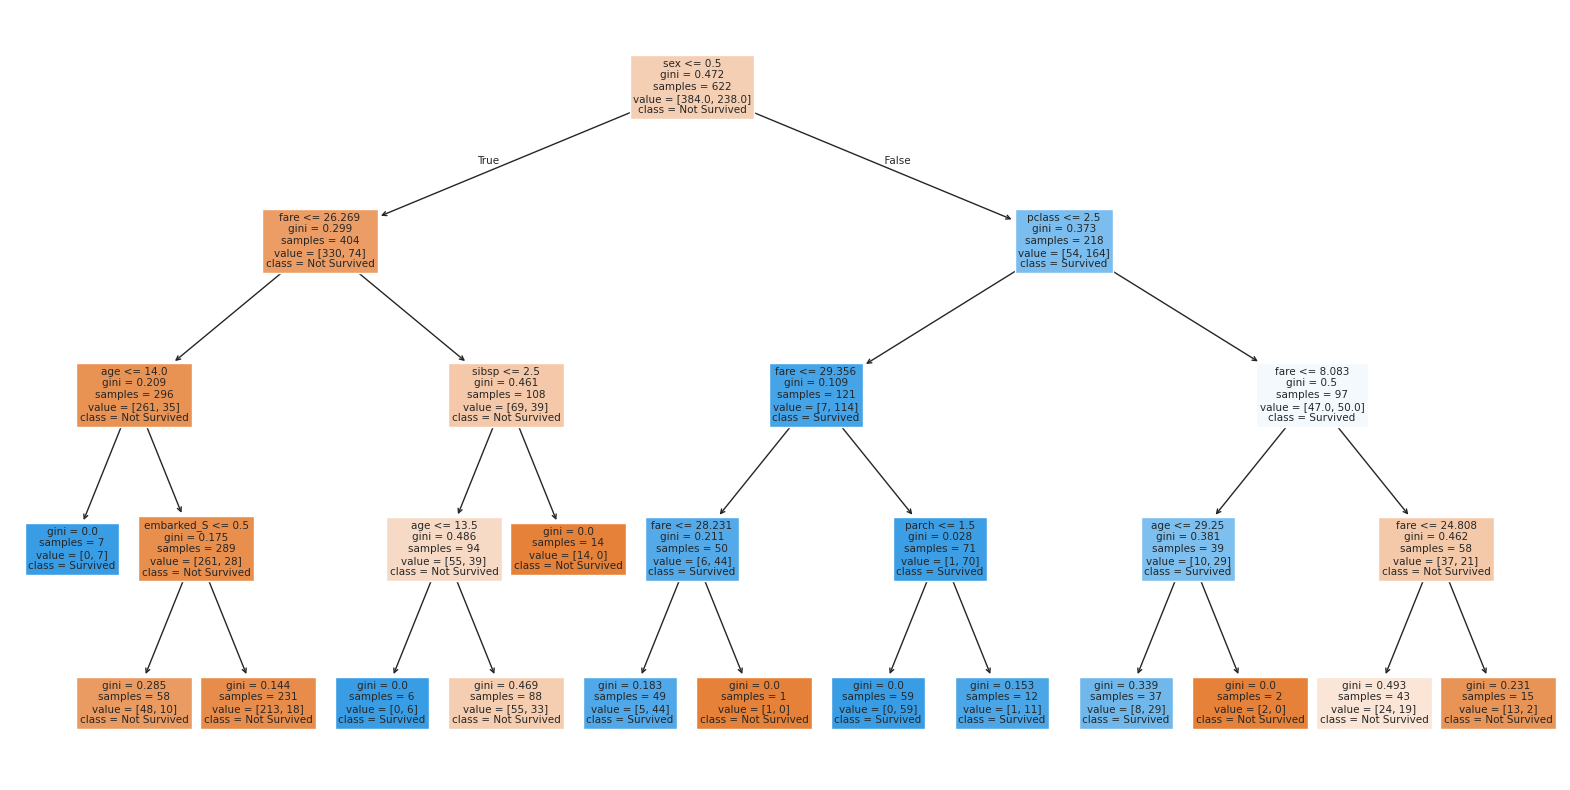

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Обучение модели
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.show()


Воспользуйтесь методом [feature_importances_](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_) для определения важности признаков вашего дерева решений. Какие признаки оказались наиболее важными? Как можно интерпретировать модель для понимания факторов выживания? (2 б доп)

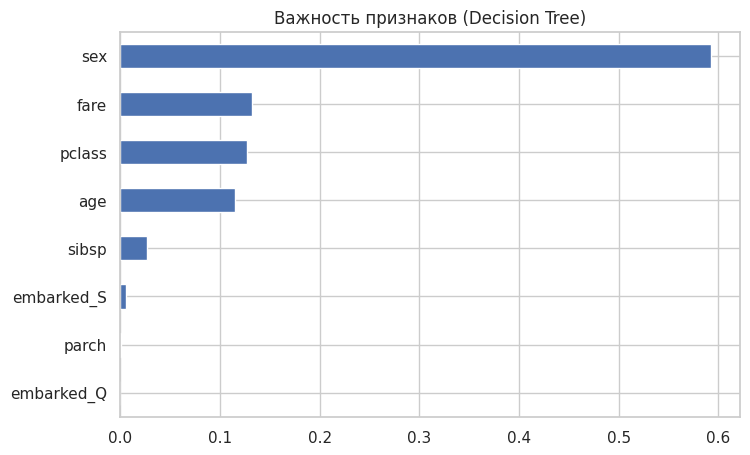

In [45]:
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Важность признаков (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()# Ваш код здесь

 Самыми важными признаками оказались:
 1. sex - сильнейший фактор выживания. Женщины выживали чаще
 2. fare - косвенно отражает социальный статус и класс
 3. pclass - пассажиры 1 класса имели преимущество
 4. age - дети и молодые люди выживали чаще

Менее значимыми оказались: sibsp, parch и embarked

 Интерпретация:
 Дерево решений подтверждает исторические данные: приоритет отдавался женщинам, детям и богатым пассажирам
 Это делает модель интерпретируемой и полезной для объяснения факторов выживания


### Задание 8 - GridSearchCV (1.5 б)

Найдите оптимальные параметры для `LogisticRegression` с помощью `GridSearchCV` с 7ю фолдами.
  - попробуйте параметры пять различных параметров для 'C' и 'penalty' = 'l2'. (1 б)
  - используйте выбранную вами метрику для оценки вашего GridSearch (параметр `scoring`) (0.5 б)

In [54]:
from sklearn.model_selection import GridSearchCV

# Сетка параметров
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # 5 параментров
    'penalty': ['l2'],
    'solver': ['liblinear']  # совместим с l2
}

# Модель
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Поиск с кросс-валидацией
grid = GridSearchCV(estimator=log_reg,
                    param_grid=param_grid,
                    cv=7,
                    scoring='f1',
                    n_jobs=-1)

# Обучение
grid.fit(X_train, y_train)

# Лучшие параметры
print(grid.best_params_)
print(grid.best_score_)


{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.724529447148745


### Задание 9 - Pipeline (1 б)

Постройте `Pipeline`, включающий любой способ масштабирования признаков и обучение SVM модели.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Построение пайплайна
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),     # масштабирование
    ('svm', SVC(kernel='linear'))     # SVM
])

# Обучение пайплайна
svm_pipeline.fit(X_train, y_train)

# Оценка
print(svm_pipeline.score(X_test, y_test))


0.7677902621722846


### Задание 10 - сравнение моделей (1 б)

Постройте `classification report` для ваших моделей. Какой алгоритм лучше и почему?

In [52]:
from sklearn.metrics import classification_report


In [56]:
# Предсказания
svm_pred = svm_pipeline.predict(X_test)
grid_pred = grid.predict(X_test)

In [57]:
print(classification_report(y_test, svm_pred))
print(classification_report(y_test, grid_pred))


              precision    recall  f1-score   support

           0       0.80      0.84      0.82       165
           1       0.71      0.66      0.68       102

    accuracy                           0.77       267
   macro avg       0.76      0.75      0.75       267
weighted avg       0.77      0.77      0.77       267



NameError: name 'tree_pred' is not defined

### Задание 11 - kNN (3 б)

Постройте `Pipeline` для выбора `kNN` модели. Используйте стандартизацию для масштабирования признаков. С помощью `GridSearchCV` c 5ю фолдами найдите оптимальный `k` и метрику подсчета расстояния до соседей. Переберите не менее 5ти значений `k` и 2ух `metric`. На каких параметрах модель показала лучшее качество по выбранной вами метрике?

In [59]:
from sklearn.neighbors import KNeighborsClassifier

# Построение пайплайна
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Сетка параметров
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],            # 5 значений k
    'knn__metric': ['euclidean', 'manhattan']       # 2 метрики расстояния
}

# GridSearchCV с 5 фолдами и метрикой F1
grid_knn = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_knn.best_params_)
print("Лучший f1-скор:", grid_knn.best_score_)

# Оценка на тесте
from sklearn.metrics import classification_report
y_pred = grid_knn.predict(X_test)
print("Classification report:\n")
print(classification_report(y_test, y_pred))


Лучшие параметры: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5}
Лучший f1-скор: 0.7391766939319243
Classification report:

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       165
           1       0.71      0.65      0.68       102

    accuracy                           0.76       267
   macro avg       0.75      0.74      0.75       267
weighted avg       0.76      0.76      0.76       267



### Задание 12 - AUC-ROC (2 б)

Постройте ROC-кривые для лучше модели каждого вида и вычислите AUC. Почему AUC важна при дисбалансе классов?

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve

# Предсказания вероятностей для класса 1
y_proba = grid_knn.predict_proba(X_test)[:, 1]

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)


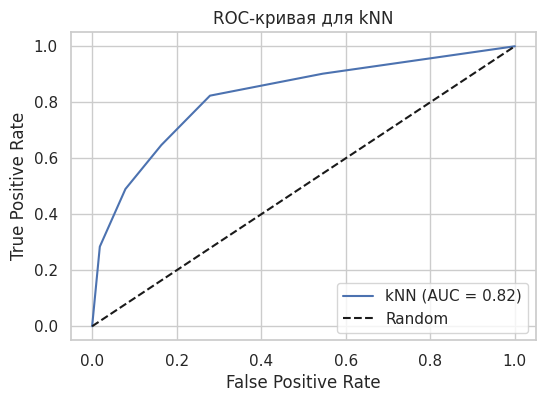

AUC: 0.821301247771836


In [61]:

# Визуализация
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'kNN (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для kNN')
plt.legend()
plt.grid(True)
plt.show()

print("AUC:", auc_score)

#Модель kNN с параметрами:
 n_neighbors = 5
 metric = 'euclidean'
 показала AUC = 0.82 на тестовой выборке.

модель хорошо различает классы — выживших и невыживших.

AUC показывает, насколько хорошо модель может различать классы независимо от порога

Интерпретация:
AUC = 0.5 — модель случайна
AUC = 0.7–0.8 — модель удовлетворительная
AUC > 0.8 — модель хорошая

Таким образом, kNN справляется с задачей предсказания выживания довольно эффективно.
